# Pneumonia Detection

In [1]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch.nn as nn
from torchvision import models
import torch.optim as optim

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset exploration and visualization

In [3]:
dataset_path = "/content/drive/MyDrive/chest_xray"

for split in ["train", "test", "val"]:

    print(f"\n{split.upper()}")

    split_path = os.path.join(dataset_path, split)

    for cls in os.listdir(split_path):

        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):

            print(
                f"{cls}: {len(os.listdir(cls_path))}"
            )


TRAIN
PNEUMONIA: 3875
NORMAL: 1341

TEST
NORMAL: 234
PNEUMONIA: 390

VAL
PNEUMONIA: 8
NORMAL: 8


Visualizing the dataset

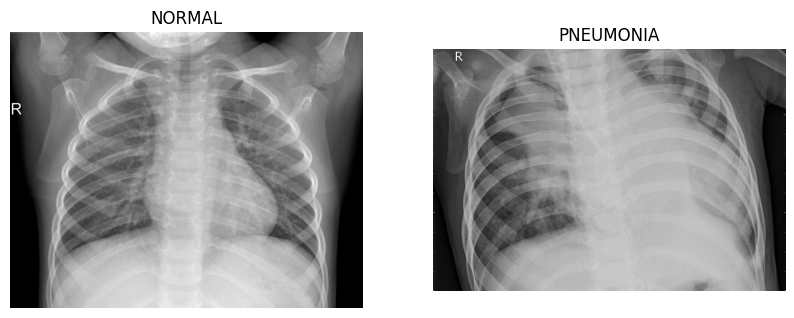

In [7]:
normal_dir = os.path.join(dataset_path, "train", "NORMAL")
pneumonia_dir = os.path.join(dataset_path, "train", "PNEUMONIA")

normal_img = os.listdir(normal_dir)[0]
pneumonia_img = os.listdir(pneumonia_dir)[0]

normal_img_path = os.path.join(normal_dir, normal_img)
pneumonia_img_path = os.path.join(pneumonia_dir, pneumonia_img)

normal = Image.open(normal_img_path)
pneumonia = Image.open(pneumonia_img_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(normal, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [10]:
print("Normal image size:", normal.size)
print("Pneumonia image size:", pneumonia.size)

Normal image size: (1696, 1330)
Pneumonia image size: (1128, 776)


In [11]:
print("Normal mode:", normal.mode)
print("Pneumonia mode:", pneumonia.mode)

Normal mode: L
Pneumonia mode: L


Class Distribution:

NORMAL: 1341
PNEUMONIA: 3875


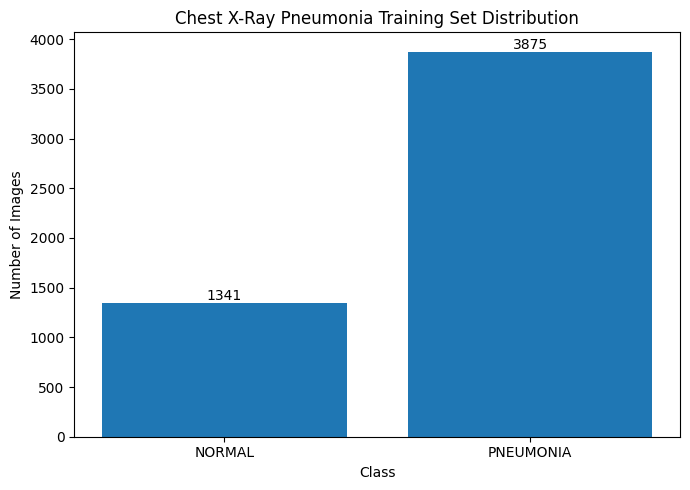

In [52]:
import os
import matplotlib.pyplot as plt

train_path = "/content/chest_xray/train"

classes = []
counts = []

for cls in sorted(os.listdir(train_path)):

    class_path = os.path.join(train_path, cls)

    if os.path.isdir(class_path):

        num_images = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(
                os.path.join(class_path, f)
            )
        ])

        classes.append(cls)
        counts.append(num_images)

print("Class Distribution:\n")

for cls, count in zip(classes, counts):
    print(f"{cls}: {count}")

plt.figure(figsize=(7,5))

bars = plt.bar(
    classes,
    counts
)

plt.title(
    "Chest X-Ray Pneumonia Training Set Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [12]:
data_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [13]:
train_dataset_path = "/content/drive/MyDrive/chest_xray/train"

In [14]:
train_dataset = datasets.ImageFolder(
    root=train_dataset_path,
    transform=data_transforms
)

In [15]:
print("Number of images:", len(train_dataset))
print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

Number of images: 5216
Classes: ['NORMAL', 'PNEUMONIA']
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [16]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
0


# Model loading , training & testing

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [18]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([1, 0, 0, 1, 1, 1, 1, 1, 0, 0])


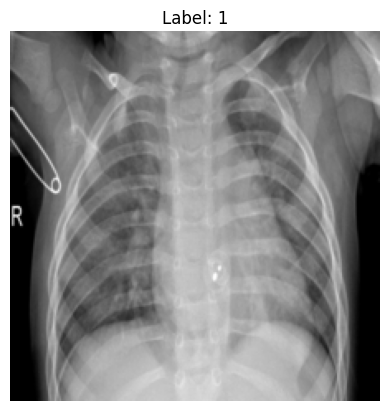

In [19]:
plt.imshow(images[0].permute(1,2,0))
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [20]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

print(train_size)
print(val_size)

4172
1044


In [21]:
train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

In [22]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 4172
Validation: 1044


In [24]:
val_images, val_labels = next(iter(val_loader))

print(val_images.shape)
print(val_labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [25]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [26]:
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [27]:
model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=2
)

print(model.fc)

Linear(in_features=2048, out_features=2, bias=True)


In [28]:
for param in model.parameters():
    param.requires_grad = False

In [29]:
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

In [30]:
model.fc.weight.requires_grad

True

In [31]:
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [32]:
criterion = nn.CrossEntropyLoss()

In [33]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [40]:
!cp -r "/content/drive/MyDrive/chest_xray" "/content/"

In [41]:
dataset_path = "/content/chest_xray"
train_dataset_path = "/content/chest_xray/train"

In [42]:
model = model.to(device)

In [44]:
model.train()

running_loss = 0.0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    if batch_idx % 20 == 0:
        print(
            f"Batch {batch_idx}/{len(train_loader)}"
        )

print(
    "Average Loss:",
    running_loss / len(train_loader)
)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ed2c55516c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ed2c55516c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Average Loss: 0.17316198201124905


In [45]:
model.eval()

correct = 0
total = 0

val_loss = 0.0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Loss:", val_loss / len(val_loader))
print("Validation Accuracy:", accuracy)

Validation Loss: 0.15420119148312192
Validation Accuracy: 94.82758620689656


In [46]:
torch.save(
    model.state_dict(),
    "resnet50_pneumonia_v1.pth"
)

In [47]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[248  25]
 [ 29 742]]


In [48]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [49]:
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias


In [50]:
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [51]:
train_losses = []

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.1043
Epoch [2/5] Loss: 0.0128
Epoch [3/5] Loss: 0.0042
Epoch [4/5] Loss: 0.0030
Epoch [5/5] Loss: 0.0027


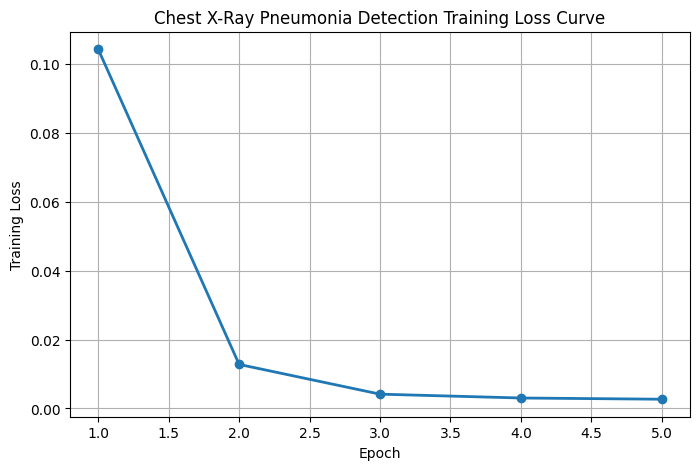

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker='o',
    linewidth=2
)

plt.title(
    "Chest X-Ray Pneumonia Detection Training Loss Curve"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.grid(True)

plt.show()

In [53]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

val_loss = 0.0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"Validation Loss: {val_loss / len(val_loader):.4f}")
print(f"Validation Accuracy: {accuracy:.2f}%")

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

Validation Loss: 0.0596
Validation Accuracy: 97.89%

Confusion Matrix:
[[265   8]
 [ 14 757]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.97      0.96       273
   PNEUMONIA       0.99      0.98      0.99       771

    accuracy                           0.98      1044
   macro avg       0.97      0.98      0.97      1044
weighted avg       0.98      0.98      0.98      1044



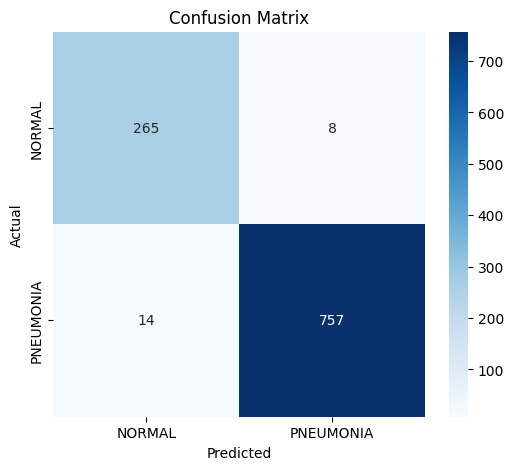

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [55]:
torch.save(
    model.state_dict(),
    "resnet50_pneumonia_v2.pth"
)

In [57]:

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, "checkpoint_v2.pth")

In [58]:
model = models.resnet50(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model.load_state_dict(
    torch.load(
        "resnet50_pneumonia_v2.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [64]:
from google.colab import files

files.download(
    "resnet50_pneumonia_v2.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
def predict_image(image_path):

    image = Image.open(image_path).convert("L")

    image = data_transforms(image)

    image = image.unsqueeze(0)

    image = image.to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(image)

        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(
            probabilities,
            1
        )


    normal_prob = probabilities[0][0].item() * 100
    pneumonia_prob = probabilities[0][1].item() * 100

    prediction = (
        "NORMAL"
        if normal_prob > pneumonia_prob
        else "PNEUMONIA"
    )

    print(f"Prediction: {prediction}")
    print(f"NORMAL: {normal_prob:.2f}%")
    print(f"PNEUMONIA: {pneumonia_prob:.2f}%")
    print(
        f"Confidence: {confidence.item()*100:.2f}%"
    )

In [60]:
from google.colab import files

uploaded = files.upload()

Saving pneumonia.png to pneumonia.png


In [61]:
image_path = list(uploaded.keys())[0]

print(image_path)

pneumonia.png


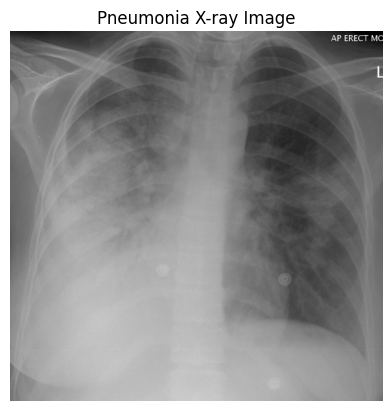

In [62]:
img = Image.open(image_path)
plt.title("Pneumonia X-ray Image")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [63]:
predict_image(image_path)

Prediction: PNEUMONIA
NORMAL: 0.01%
PNEUMONIA: 99.99%
Confidence: 99.99%


In [65]:
uploaded = files.upload()

image_path2 = list(uploaded.keys())[0]

Saving normal.jpg to normal.jpg


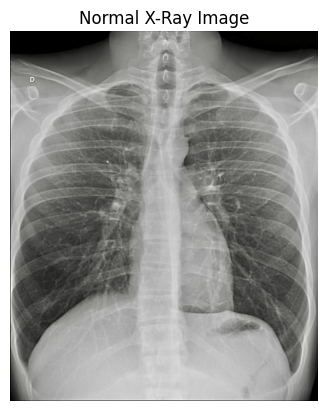

In [66]:
img = Image.open(image_path2)

plt.title("Normal X-Ray Image")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [67]:
predict_image(image_path2)

Prediction: NORMAL
NORMAL: 99.79%
PNEUMONIA: 0.21%
Confidence: 99.79%


# Grad Cam

In [73]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def visualize_gradcam(image_path):

    image = Image.open(image_path).convert("L")

    rgb_image = image.convert("RGB")

    input_tensor = data_transforms(image)

    input_tensor = input_tensor.unsqueeze(0)

    input_tensor = input_tensor.to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        pred_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = (
            probabilities[0][pred_class].item()
            * 100
        )

    class_names = [
        "NORMAL",
        "PNEUMONIA"
    ]

    print(
        f"\nPrediction: "
        f"{class_names[pred_class]}"
    )

    print(
        f"Confidence: "
        f"{confidence:.2f}%"
    )

    print("\nClass Probabilities:\n")

    for idx, cls in enumerate(class_names):

        print(
            f"{cls:<12}: "
            f"{probabilities[0][idx].item()*100:.2f}%"
        )

    target_layers = [
        model.layer4[-1]
    ]

    cam = GradCAMPlusPlus(
        model=model,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(
            pred_class
        )
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

    grayscale_cam = grayscale_cam[0]

    rgb_np = np.array(
        rgb_image.resize((224,224))
    ).astype(np.float32) / 255.0

    visualization = show_cam_on_image(
        rgb_np,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(rgb_np)
    plt.title("Original X-Ray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(
        grayscale_cam,
        cmap="jet"
    )
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(
        visualization
    )
    plt.title(
        f"{class_names[pred_class]} "
        f"({confidence:.2f}%)"
    )
    plt.axis("off")

    plt.tight_layout()

    plt.show()


Prediction: PNEUMONIA
Confidence: 99.99%

Class Probabilities:

NORMAL      : 0.01%
PNEUMONIA   : 99.99%


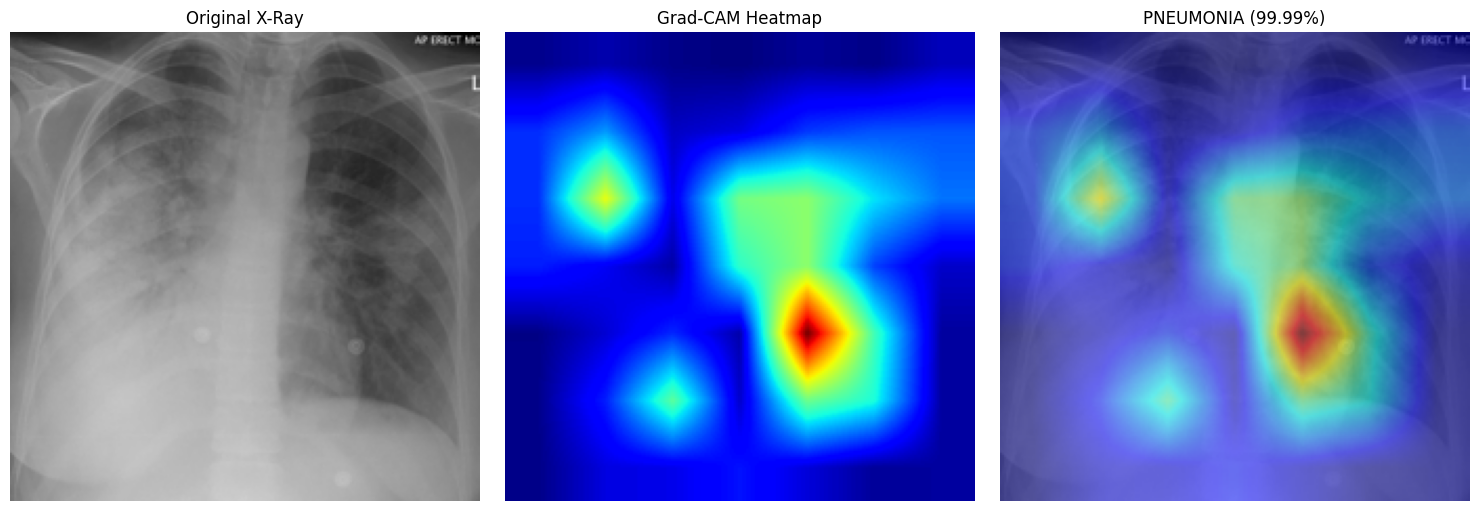

In [75]:
visualize_gradcam(image_path)


Prediction: NORMAL
Confidence: 99.79%

Class Probabilities:

NORMAL      : 99.79%
PNEUMONIA   : 0.21%


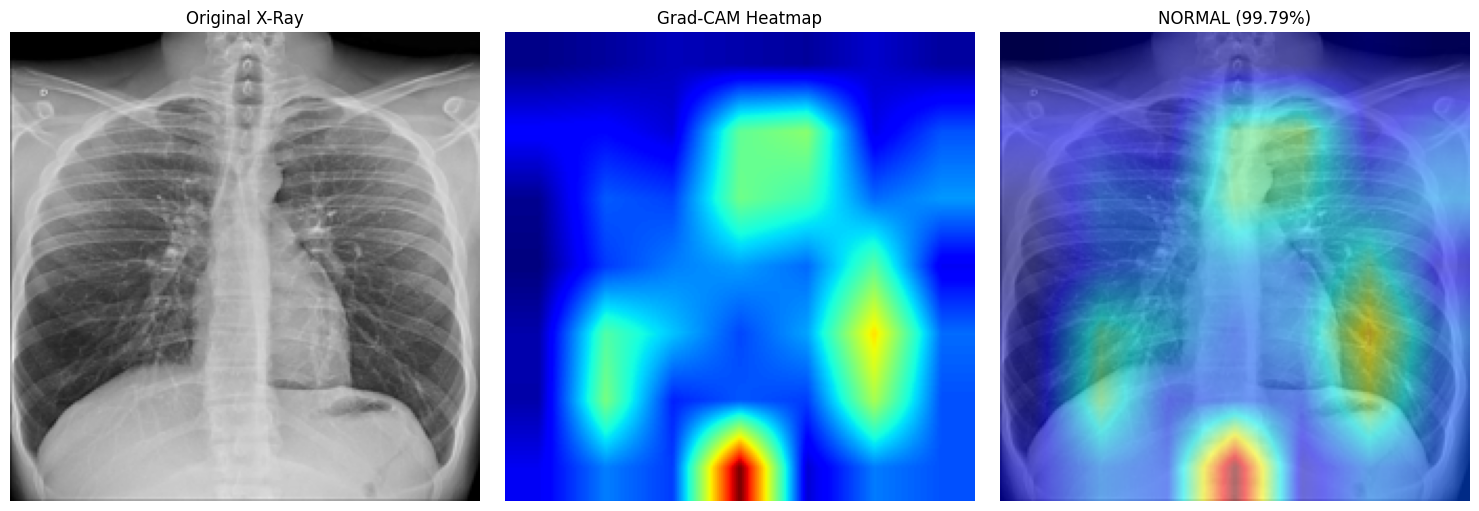

In [76]:
visualize_gradcam(image_path2)